<h1>Prophet package</h1>

In [54]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from main import *
import numpy as np
from sklearn.metrics import mean_squared_error

In [55]:
number_mimo = 4
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 3
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)

ds = Data_selector(df)
df_modified = ds.select_peaks(goodness=3)

feature_selector = Feature_selector(df_modified, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season"] + ["datetime"]
feature_selector.select(features_to_select=features_to_be_select)

In [56]:
preprocessed_df = feature_selector.df
power_plants = preprocessed_df[['name', 'code']].drop_duplicates()
preprocessed_df.rename(columns={"datetime": "ds", "generation": "y"}, inplace=True)

categorical_cols = preprocessed_df.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop("ds")
preprocessed_df = pd.get_dummies(preprocessed_df, columns=categorical_cols, drop_first=True)
preprocessed_df.columns = preprocessed_df.columns.astype(str)

C:\Users\S.H.Jasbi\AppData\Local\Temp\ipykernel_3960\15015744.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preprocessed_df.rename(columns={"datetime": "ds", "generation": "y"}, inplace=True)


In [63]:
test_rmses = []
train_rmses = []

for _, row in power_plants.iterrows():
    mask = (df_modified["name"] == row['name']) & (df_modified['code'] == row['code'])
    
    df_name_code = preprocessed_df[mask]
    test_size = int(len(df_name_code) / 5)
    train_df = df_name_code.iloc[:-test_size]
    test_df = df_name_code.iloc[-test_size:]

    model = Prophet()
    for col in df_name_code.columns:
        if col in ['ds', 'y']: continue
        model.add_regressor(col)
    model.fit(train_df)
    
    future_test = test_df.drop(columns=['y'])
    forecast_test = model.predict(future_test)
    y_true_test = test_df['y'].values
    y_pred_test = forecast_test['yhat'].values

    test_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test)) / np.mean(y_true_test) * 100
    test_rmses.append(test_rmse)
    print(f"Test Error: {test_rmse:0.2f}%")
    
    future_train = train_df.drop(columns=['y'])
    forecast_train = model.predict(future_train)
    y_true_train = train_df['y'].values
    y_pred_train = forecast_train['yhat'].values
    
    train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train)) / np.mean(y_true_train) * 100
    train_rmses.append(train_rmse)
    print(f"Train Error: {train_rmse:0.2f}%")
    
    

17:21:46 - cmdstanpy - INFO - Chain [1] start processing
17:21:49 - cmdstanpy - INFO - Chain [1] done processing


Test Error: 5.16%


17:21:50 - cmdstanpy - INFO - Chain [1] start processing


Train Error: 1.73%


17:21:51 - cmdstanpy - INFO - Chain [1] done processing


...

Test Error: 1.93%
Train Error: 4.47%


17:23:06 - cmdstanpy - INFO - Chain [1] start processing
17:23:07 - cmdstanpy - INFO - Chain [1] done processing


Test Error: 2.69%
Train Error: 3.82%


17:23:08 - cmdstanpy - INFO - Chain [1] start processing
17:23:09 - cmdstanpy - INFO - Chain [1] done processing


Test Error: 2.20%
Train Error: 1.07%


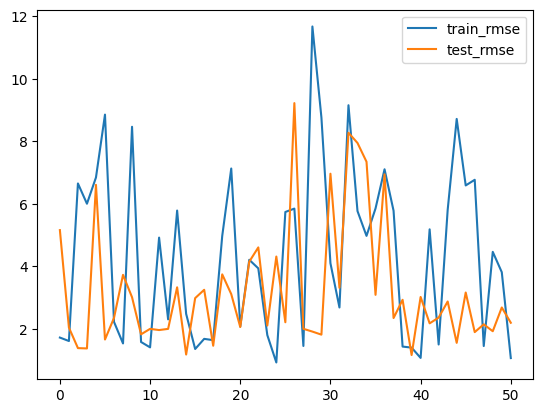

In [64]:
import matplotlib.pyplot as plt

# model.plot(forecast)
# plt.show()


plt.plot(train_rmses, label = "train_rmse")
plt.plot(test_rmses, label = "test_rmse")
plt.legend()
plt.show()

In [65]:
print(np.mean(test_rmses))
print(np.mean(train_rmses))


3.2357094236892032
4.320914080479658
